In [2]:
import numpy as np 
import rasterio
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from rasterio.plot import show
import matplotlib.pyplot as plt
from tqdm import tqdm  

In [3]:
# Only run initially!!

#from zipfile import ZipFile

#dc_zip = './data/Washington_DC_Boundary.zip'
#dc_out = './data/DC_shp'

#with ZipFile(dc_zip, 'r') as zObject:
    # Extract downloaded land cover data and store in data > land_cover folder
#    zObject.extractall(path = dc_out)

In [2]:
# Read in
dc = gpd.read_file('./data/DC_shp/Washington_DC_Boundary.shp')

# Reproject
dc = dc.to_crs('epsg:5070')

In [18]:
# Clip land cover raster to DC extent
# https://gis.stackexchange.com/questions/444062/clipping-raster-geotiff-with-a-vector-shapefile-in-python

land_cover = './data/land_cover/land_cover_standardized.tif'
land_cover_DC = './data/DC_TEST/land_cover_dc.tif'

with rasterio.open(land_cover) as src:
    print(f'dc shp crs = land_cover crs: {dc.crs == src.crs}')
    out_image, out_transform=mask(src, dc.geometry, crop=True)
    out_meta = src.meta.copy() # Copy src metadata
    
out_meta.update({
    'driver':'Gtiff',
    'height':out_image.shape[1], # Height starts with shape[1]
    'width':out_image.shape[2], # Width starts with shape[2]
    'transform':out_transform
})
              
with rasterio.open(land_cover_DC,'w',**out_meta) as dst:
    dst.write(out_image)

dc shp crs = land_cover crs: True


{'driver': 'GTiff', 'dtype': 'float32', 'nodata': -10.0, 'width': 623, 'height': 748, 'count': 1, 'crs': CRS.from_wkt('PROJCS["NAD83 / Conus Albers",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4269"]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude_of_center",23],PARAMETER["longitude_of_center",-96],PARAMETER["standard_parallel_1",29.5],PARAMETER["standard_parallel_2",45.5],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","5070"]]'), 'transform': Affine(30.0, 0.0, 1610745.0,
       0.0, -30.0, 1936215.0), 'blockxsize': 623, 'blockysize': 3, 'tiled': False, 'interleave': 'band'}


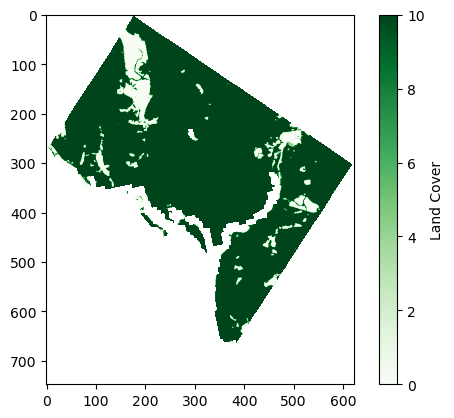

In [2]:
# Plot land cover
land_cover_DC = './data/DC_TEST/land_cover_dc.tif'

with rasterio.open(land_cover_DC) as src:
    print(src.profile)
    arr = src.read(1, masked = True)
    plt.imshow(arr, cmap = 'Greens', vmin = 0, vmax = 10)
    plt.colorbar(label = 'Land Cover')

In [3]:
# CODE FOR DETERMINING THE % SUITABILITY FOR EACH INDIVIDUAL CRITERIA
# % Suitable land cover
# Cells with value of 10 / total number of cells that are not nodata

land_cover_DC = './data/DC_TEST/land_cover_dc.tif'

total_high_suitability = 0
total_nodata = 0

with rasterio.open(land_cover_DC) as src:

    # Total number of blocks
    total_blocks = sum(1 for _ in src.block_windows(1))
    print(f'Total blocks: {total_blocks}')

    for ji, window in tqdm(src.block_windows(1), total = total_blocks, desc = 'Block window processing'):
        data = src.read(1, window = window, masked = True)

        #total_high_suitability += np.count_nonzero((data == 10) | (data == 4) | (data == 0))
        total_high_suitability += np.count_nonzero(data == 10)

        total_nodata += np.sum(data.mask) # Calculates the total number of nodata cells

    all_cells = src.width * src.height

    all_NON_nodata_cells = all_cells - total_nodata

    percent_high_suitability = total_high_suitability / all_NON_nodata_cells
    print(f'% high suitability (10): {percent_high_suitability}')

Total blocks: 250


Block window processing: 100%|██████████| 250/250 [00:00<00:00, 3102.84it/s]

% high suitability (10): 0.8959587995504186


In [6]:
# % Suitable land cover
# Cells with value of >8 and <10 / total number of cells that are not nodata

land_cover_DC = './data/DC_TEST/land_cover_dc.tif'

total_high_suitability = 0
total_nodata = 0

with rasterio.open(land_cover_DC) as src:

    # Total number of blocks
    total_blocks = sum(1 for _ in src.block_windows(1))
    print(f'Total blocks: {total_blocks}')

    for ji, window in tqdm(src.block_windows(1), total = total_blocks, desc = 'Block window processing'):
        data = src.read(1, window = window, masked = True)

        total_high_suitability += np.count_nonzero((data > 8) & (data <= 10))
        #total_high_suitability += np.count_nonzero(data == 10)

        total_nodata += np.sum(data.mask) # Calculates the total number of nodata cells

    all_cells = src.width * src.height

    all_NON_nodata_cells = all_cells - total_nodata

    percent_high_suitability = total_high_suitability / all_NON_nodata_cells
    print(f'% high suitability (10): {percent_high_suitability}')

Total blocks: 250


Block window processing: 100%|██████████| 250/250 [00:00<00:00, 2894.16it/s]

% high suitability (10): 0.8959587995504186


In [20]:
# Clip projected prcip ssp2 2025 raster to DC extent
# https://gis.stackexchange.com/questions/444062/clipping-raster-geotiff-with-a-vector-shapefile-in-python

prcp_2025 = './data/projected_precip/precip_ssp2_2025/ssp2_2025_prcp_rate_standardized.tif'
prcp_2025_DC = './data/DC_TEST/prcp_2025_dc.tif'

with rasterio.open(prcp_2025) as src:
    print(f'dc shp crs = prcp crs: {dc.crs == src.crs}')
    out_image, out_transform=mask(src, dc.geometry, crop=True)
    out_meta = src.meta.copy() # Copy src metadata
    
out_meta.update({
    'driver':'Gtiff',
    'height':out_image.shape[1], # Height starts with shape[1]
    'width':out_image.shape[2], # Width starts with shape[2]
    'transform':out_transform
})
              
with rasterio.open(prcp_2025_DC,'w',**out_meta) as dst:
    dst.write(out_image)

dc shp crs = land_cover crs: True


{'driver': 'GTiff', 'dtype': 'float32', 'nodata': -10.0, 'width': 623, 'height': 748, 'count': 1, 'crs': CRS.from_wkt('PROJCS["NAD83 / Conus Albers",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4269"]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude_of_center",23],PARAMETER["longitude_of_center",-96],PARAMETER["standard_parallel_1",29.5],PARAMETER["standard_parallel_2",45.5],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","5070"]]'), 'transform': Affine(30.0, 0.0, 1610745.0,
       0.0, -30.0, 1936215.0), 'blockxsize': 623, 'blockysize': 3, 'tiled': False, 'interleave': 'band'}


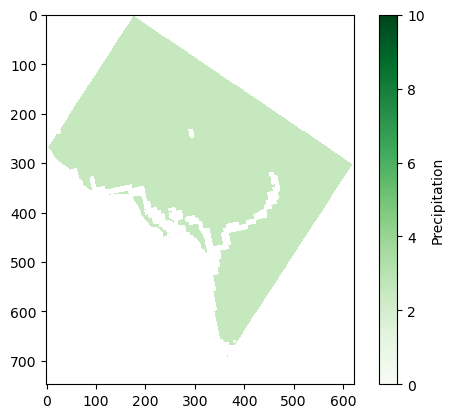

In [3]:
# Plot precip 2025
prcp_2025_DC = './data/DC_TEST/prcp_2025_dc.tif'

with rasterio.open(prcp_2025_DC) as src:
    print(src.profile)
    arr = src.read(1, masked = True)
    plt.imshow(arr, cmap = 'Greens', vmin = 0, vmax = 10)
    plt.colorbar(label = 'Precipitation')

In [1]:
import georasters as gr

ModuleNotFoundError: No module named 'georasters'

In [ ]:
prcp_2025_DC = './data/DC_TEST/prcp_2025_dc.tif'


In [15]:
# Extracting precip raster values into pandas df - only code that runs so far!!!!!!!
prcp_2025_DC = './data/DC_TEST/prcp_2025_dc.tif'

src= rasterio.open(prcp_2025_DC)
# number of bands
print(f'Bands: {src.count}')

array = src.read()

import pandas as pd

# convert to a DataFrame
df = pd.DataFrame()
df['precip_rate'] = array[0].ravel() 
 
df.head()

#with rasterio.open(prcp_2025_DC) as src:
    # For each block window
 #   for ji, window in tqdm(srcs[0].block_windows(1), total = total_blocks, desc = 'Block window processing'):
  #     data = src.read(1, window = window)
src.close() 

Bands: 1


In [16]:
print(df.shape)
df.head()


(466004, 1)


,precip_rate
0,-10.0
1,-10.0
2,-10.0
3,-10.0
4,-10.0


In [21]:
# Extract df from raster values
prcp_2025_DC = './data/DC_TEST/prcp_2025_dc.tif'

precip_df = pd.DataFrame()

with rasterio.open(prcp_2025_DC) as src:
    total_blocks = sum(1 for _ in src.block_windows(1))
    print(f'Total blocks {total_blocks}')
    
    # For each block window
    for ji, window in tqdm(src.block_windows(1), total = total_blocks, desc = 'Block window processing'):
        data = src.read(1, window = window)
        
        precip_df['precip_rate'] = data[0].ravel()


Total blocks 250


Block window processing: 100%|██████████| 250/250 [00:00<00:00, 6934.29it/s]


In [23]:

prcp_2025_DC = './data/DC_TEST/prcp_2025_dc.tif'

values = []

with rasterio.open(prcp_2025_DC) as src:
    total_blocks = sum(1 for _ in src.block_windows(1))
    print(f'Total blocks {total_blocks}')
    
    for ji, window in tqdm(
        src.block_windows(1),
        total=total_blocks,
        desc='Block window processing'
    ):
        data = src.read(1, window=window)
        values.append(data.ravel())

precip_df = pd.DataFrame({
    "precip_rate": np.concatenate(values)
})


Total blocks 250


Block window processing: 100%|██████████| 250/250 [00:00<00:00, 12447.19it/s]


In [32]:
x = np.concatenate(values)
y = pd.DataFrame({'col' : x})
y

,col
0,-10.0
1,-10.0
2,-10.0
3,-10.0
4,-10.0
...,...
465999,-10.0
466000,-10.0
466001,-10.0
466002,-10.0


In [24]:
precip_df.shape

(466004, 1)

In [27]:
# Remove -10s from df - next bloxk
precip_df['precip_rate'].min()

-10.0

In [20]:
nodata = -10
df_new = df[df['precip_rate'] != nodata]
df_new

,precip_rate
799,2.533693
800,2.533753
1421,2.533601
1422,2.533662
1423,2.533722
...,...
433351,2.528542
433972,2.528308
433973,2.528411
433974,2.528514


In [25]:
print(df.equals(precip_df)) # df was created by reading in the whole array - not feasible for large rasters

True


In [7]:

fp = './data/DC_TEST/'
prcp_2025_DC = './data/DC_TEST/prcp_2025_dc.tif'

with rasterio.open(prcp_2025_DC) as src:
    
    # Get total blocks
    total_blocks = sum(1 for _ in src.block_windows(1))
    print(f'Total blocks {total_blocks}')

    # Go thru each window
    for ji, window in tqdm(src.block_windows(1), total = total_blocks, desc = 'Block window processing'):
        image = src.read(1, window = window)

        # Transform
        #bands, rows, cols = np.shape(image)
        rows, cols = np.shape(image)
        #image1 = image.reshape (rows*cols,bands)
        image1 = image.reshape (rows*cols)

        print(np.shape(image1))

        # Bounding box
        l,b,r,t = src.bounds

        # Res
        res = src.res

        # meshgrid of X and Y
        x = np.arange(l,r, res[0])
        y = np.arange(t,b, -res[0])
        X,Y = np.meshgrid(x,y)
        print (np.shape(X))
        # flatten X and Y
        newX = np.array(X.flatten())
        newY = np.array(Y.flatten())
        print (np.shape(newX))
        # join XY and Z information
        export = np.column_stack((newX, newY, image1))
        fname='XYZ.csv'
        with open(fname, 'w') as fp:
            a = csv.writer(fp, delimiter=',')
            a.writerows(export)
            fp.close() # close file



Total blocks 250


Block window processing:   0%|          | 0/250 [00:00<?, ?it/s]

(1869,)
(748, 623)
(466004,)


ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 466004 and the array at index 2 has size 1869

In [22]:
# Clip projected watershed impairment raster to DC extent
# https://gis.stackexchange.com/questions/444062/clipping-raster-geotiff-with-a-vector-shapefile-in-python

impairment = './data/watershed_impairment/impairment_standardized.tif'
impairment_DC = './data/DC_TEST/impairment_dc.tif'

with rasterio.open(impairment) as src:
    print(f'dc shp crs = impairment crs: {dc.crs == src.crs}')
    out_image, out_transform=mask(src, dc.geometry, crop=True)
    out_meta = src.meta.copy() # Copy src metadata
    
out_meta.update({
    'driver':'Gtiff',
    'height':out_image.shape[1], # Height starts with shape[1]
    'width':out_image.shape[2], # Width starts with shape[2]
    'transform':out_transform
})
              
with rasterio.open(impairment_DC,'w',**out_meta) as dst:
    dst.write(out_image)

dc shp crs = impairment crs: True


{'driver': 'GTiff', 'dtype': 'float32', 'nodata': -10.0, 'width': 623, 'height': 748, 'count': 1, 'crs': CRS.from_wkt('PROJCS["NAD83 / Conus Albers",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4269"]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude_of_center",23],PARAMETER["longitude_of_center",-96],PARAMETER["standard_parallel_1",29.5],PARAMETER["standard_parallel_2",45.5],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","5070"]]'), 'transform': Affine(30.0, 0.0, 1610745.0,
       0.0, -30.0, 1936215.0), 'blockxsize': 623, 'blockysize': 3, 'tiled': False, 'interleave': 'band'}


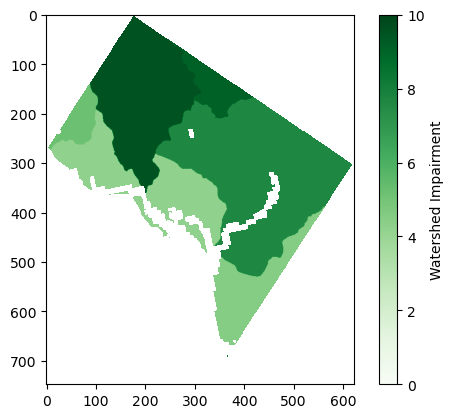

In [6]:
# Plot impairment
impairment_DC = './data/DC_TEST/impairment_dc.tif'

with rasterio.open(impairment_DC) as src:
    print(src.profile)
    arr = src.read(1, masked = True)
    plt.imshow(arr, cmap = 'Greens', vmin = 0, vmax = 10)
    plt.colorbar(label = 'Watershed Impairment')

In [3]:
# Rasters and weights for model 1:

# Rasters
land_cover = './data/DC_TEST/land_cover_dc.tif' # Land cover
prcp = './data/DC_TEST/prcp_2025_dc.tif' # Precipitation (SSP2 2025)
impairment = './data/DC_TEST/impairment_dc.tif' # Watershed impairment

# Weights
land_cover_weight = 0.5
prcp_weight = 0.2
impairment_weight = 0.3

in_rasters = [land_cover, prcp, impairment]
weights = [land_cover_weight, prcp_weight, impairment_weight]
for raster, weight in zip(in_rasters, weights):
    print(raster, weight)

./data/DC_TEST/land_cover_dc.tif 0.5
./data/DC_TEST/prcp_2025_dc.tif 0.2
./data/DC_TEST/impairment_dc.tif 0.3


In [22]:
# Model 1 weighted overlay

# Output
out_raster = './data/DC_TEST/output1.tif'

# Open all rasters
srcs = [rasterio.open(raster) for raster in in_rasters]

# Verify that there are the same number of srcs as there are weights
print(f'Lengh of srcs equals length of weights: {len(srcs) == len(weights)}')
for src, weight in zip(srcs, weights):
    print(src, weight)

# Copy metadata from src raster
meta = srcs[0].meta.copy()
nodata = srcs[0].nodata

meta.update(
    dtype = rasterio.float32,
    count = 1,
    nodata = nodata
)

# Total blocks
total_blocks = sum(1 for _ in srcs[0].block_windows(1))
print(f'Total blocks {total_blocks}')

# Make output raster
with rasterio.open(out_raster, 'w', **meta) as dst:
    
    # For each block window
    for ji, window in tqdm(srcs[0].block_windows(1), total = total_blocks, desc = 'Block window processing'):
        # Create an empty array of zeros
        weighted_sum = np.zeros(
            (window.height, window.width),
            dtype = rasterio.float32)

        # Create an array to store all VALID (aka not nodata) cells (starts off with all cells as valid)
        valid_array = np.ones(
            (window.height, window.width),
            dtype = bool)
        
        # Go through each variable, weighs
        for src, weight in zip(srcs, weights):
            data = src.read(1, window = window)

            # Valid cells (where the cells do not equal nodata)
            valid_cells = data!= nodata

            # Update valid_array after checking for nodata cells
            valid_array = valid_array & valid_cells # Only True if the cell is actually valid

            # Replace nodata cells with 0 to not mess up with weighted sum calculations
            data = np.where(valid_cells, data, 0)

            # Multiply the cell value by the weight 
            weighted_sum += data*weight

        # Set any nodata cells to nodata in the final output raster
        weighted_sum = np.where(valid_array, weighted_sum, nodata)

        # Write out final raster
        dst.write(weighted_sum, 1, window = window)
            

# Close all input rasters
for src in srcs:
    src.close()

Lengh of srcs equals length of weights: True
<open DatasetReader name='./data/DC_TEST/land_cover_dc.tif' mode='r'> 0.5
<open DatasetReader name='./data/DC_TEST/prcp_2025_dc.tif' mode='r'> 0.2
<open DatasetReader name='./data/DC_TEST/impairment_dc.tif' mode='r'> 0.3
Total blocks 250


Block window processing: 100%|██████████| 250/250 [00:00<00:00, 1975.85it/s]


{'driver': 'GTiff', 'dtype': 'float32', 'nodata': -10.0, 'width': 623, 'height': 748, 'count': 1, 'crs': CRS.from_wkt('PROJCS["NAD83 / Conus Albers",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4269"]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude_of_center",23],PARAMETER["longitude_of_center",-96],PARAMETER["standard_parallel_1",29.5],PARAMETER["standard_parallel_2",45.5],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","5070"]]'), 'transform': Affine(30.0, 0.0, 1610745.0,
       0.0, -30.0, 1936215.0), 'blockxsize': 623, 'blockysize': 3, 'tiled': False, 'interleave': 'band'}
min: 1.7582850456237793
max: 8.371206283569336


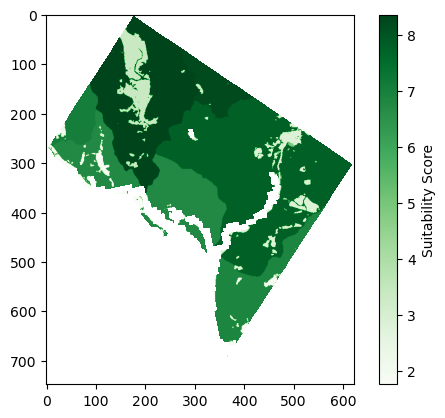

In [4]:
out_raster = './data/DC_TEST/output1.tif'

with rasterio.open(out_raster) as src:
    print(src.profile)
    arr = src.read(1, masked = True)
    plt.imshow(arr, cmap = 'Greens')#, vmin = 0, vmax = 10)
    plt.colorbar(label = 'Suitability Score')
    print(f'min: {arr.min()}')
    print(f'max: {arr.max()}')

In [22]:
# Reclassify cells

out_raster = './data/DC_TEST/output1.tif'
out_raster_reclassified = './data/DC_TEST/output1_reclassified.tif'

with rasterio.open(out_raster) as src:
    profile = src.profile.copy()
    nodata = src.nodata
    profile.update(
        dtype = rasterio.int16,
        nodata = nodata,
        #blockxsize = 128,
        #blockysize = 128,
        #tiled = True
    )

    # Total number of blocks
    total_blocks = sum(1 for _ in src.block_windows(1))
    print(f'Total blocks: {total_blocks}')

    with rasterio.open(out_raster_reclassified, 'w', **profile) as dst:

        for ji, window in tqdm(src.block_windows(1), total = total_blocks, desc = 'Block window processing'):

            data = src.read(1, window = window)
            data_copy = data.copy()

            # Reclassify:
                # [10-8] >> 1 (highly suitable)
            data_copy[(data <10) & (data >=8)] = 1
            
                # (8-6] >> 2 (moderately suitable)
            data_copy[(data <8) & (data >=6)] = 2
            
                # (6-4}] >> 3 (marginally suitable)
            data_copy[(data <6) & (data >=4)] = 3

                # (4-2] >> 4 (very unsuitable)
            data_copy[(data <4) & (data >=2)] = 4

                # (2-0] >> 5 (unsuitable)
            data_copy[(data <2) & (data >=0)] = 5

            # Write out reclassified raster
            dst.write(data_copy, 1, window = window)

Total blocks: 250


Block window processing: 100%|██████████| 250/250 [00:00<00:00, 2226.40it/s]


{'driver': 'GTiff', 'dtype': 'int16', 'nodata': -10.0, 'width': 623, 'height': 748, 'count': 1, 'crs': CRS.from_wkt('PROJCS["NAD83 / Conus Albers",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4269"]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude_of_center",23],PARAMETER["longitude_of_center",-96],PARAMETER["standard_parallel_1",29.5],PARAMETER["standard_parallel_2",45.5],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","5070"]]'), 'transform': Affine(30.0, 0.0, 1610745.0,
       0.0, -30.0, 1936215.0), 'blockxsize': 623, 'blockysize': 3, 'tiled': False, 'interleave': 'band'}
min: -10
max: 5


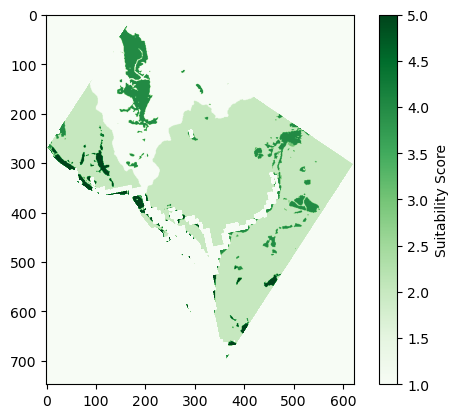

In [23]:
out_raster_reclassified = './data/DC_TEST/output1_reclassified.tif'

with rasterio.open(out_raster_reclassified) as src:
    print(src.profile)
    #arr = src.read(1, masked = True)
    arr = src.read(1)
    plt.imshow(arr, cmap = 'Greens', vmin = 1, vmax = 5)
    plt.colorbar(label = 'Suitability Score')
    print(f'min: {arr.min()}')
    print(f'max: {arr.max()}')

In [6]:
# Calculate cells that are high, med, etc sustainability

# % Suitable land cover
# Cells with value of >8 and <10 / total number of cells that are not nodata

out_raster_reclassified = './data/DC_TEST/output1_reclassified.tif'

total_1 = 0
total_2 = 0
total_3 = 0
total_4 = 0
total_5 = 0
total_nodata = 0

with rasterio.open(out_raster_reclassified) as src:

    # Total number of blocks
    total_blocks = sum(1 for _ in src.block_windows(1))
    print(f'Total blocks: {total_blocks}')

    for ji, window in tqdm(src.block_windows(1), total = total_blocks, desc = 'Block window processing'):
        data = src.read(1, window = window, masked = True)

        total_1 += np.count_nonzero(data == 1) # Total cells = 1
        total_2 += np.count_nonzero(data == 2) # Total cells = 2
        total_3 += np.count_nonzero(data == 3) # Total cells = 3
        total_4 += np.count_nonzero(data == 4) # Total cells = 4
        total_5 += np.count_nonzero(data == 5) # Total cells = 5

        total_nodata += np.sum(data.mask) # Calculates the total number of nodata cells

    all_cells = src.width * src.height

    all_NON_nodata_cells = all_cells - total_nodata

    percent_1 = total_1 / all_NON_nodata_cells
    print(f'% highly suitable (1): {percent_1}')
    
    percent_2 = total_2 / all_NON_nodata_cells
    print(f'% moderately suitable (2): {percent_2}')

    percent_3 = total_3 / all_NON_nodata_cells
    print(f'% marginally suitable (3): {percent_3}')

    percent_4 = total_4 / all_NON_nodata_cells
    print(f'% very unsuitable (4): {percent_4}')

    percent_5 = total_5 / all_NON_nodata_cells
    print(f'% absolutely unsuitable (5): {percent_5}')

    print(f'%s add to : {percent_1 + percent_2 + percent_3 + percent_4 + percent_5}')

Total blocks: 250


Block window processing: 100%|██████████| 250/250 [00:00<00:00, 3605.70it/s]

% highly suitable (1): 0.24385879563615218
% moderately suitable (2): 0.6521000039142664
% marginally suitable (3): 0.0004697119659123316
% very unsuitable (4): 0.0760765630504437
% absolutely unsuitable (5): 0.02749492543322541
%s add to : 1.0


In [ ]:
# Weights dictionary
model1_weights = {'land_cover': 0.5, 
                  'prcp_rate': 0.2, 
                  'impairment': 0.3}

model1_weights = {land_cover: 0.5, 
                  prcp: 0.2, 
                  impairment: 0.3}

for variable, weight in model1_weights.items():
    print(variable, weight)

In [ ]:
with rasterio.open(impairment_DC) as src:
    print(src.profile)

In [17]:
# Weighted overlay
# Output
out_raster = './data/DC_TEST/output1.tif'

# Open all rasters
srcs = [rasterio.open(raster) for raster in in_rasters]

# Verify that there are the same number of srcs as there are weights
print(f'Lengh of srcs equals length of weights: {len(srcs) == len(weights)}')
for src, weight in zip(srcs, weights):
    print(src, weight)

# Copy metadata from src raster
meta = srcs[0].meta.copy()
nodata = srcs[0].nodata

meta.update(
    dtype = rasterio.float32,
    count = 1,
    nodata = nodata
)

# Total blocks
total_blocks = sum(1 for _ in srcs[0].block_windows(1))
print(f'Total blocks {total_blocks}')

# Make output raster
with rasterio.open(out_raster, 'w', **meta) as dst:
    
    # Go over all block window and create a template filled with zeros
    for ji, window in tqdm(srcs[0].block_windows(1), total = total_blocks, desc = 'Processing'):
        weighted_sum = np.zeros(
            (window.height, window.width),
            dtype = rasterio.float32)
        
        # Go through each variable, weighs
        for src, weight in zip(srcs, weights):
            data = src.read(1, window = window)
            weighted_sum += data*weight

        # Write out final raster
        dst.write(weighted_sum, 1, window = window)
            

# Close all input rasters
for src in srcs:
    src.close()

Lengh of srcs equals length of weights: True
<open DatasetReader name='./data/DC_TEST/land_cover_dc.tif' mode='r'> 0.5
<open DatasetReader name='./data/DC_TEST/prcp_2025_dc.tif' mode='r'> 0.2
<open DatasetReader name='./data/DC_TEST/impairment_dc.tif' mode='r'> 0.3
Total blocks 250


Processing: 100%|██████████| 250/250 [00:00<00:00, 3058.75it/s]


In [ ]:
# Subtract present conditions from future conditions to calculate change
    # 0 = no change
    # positive values = increase in suitability
    # negative values = decrease in suitability 

current_conditions = './data/final_outputs/model1_ahp_weights_ssp2_2025_RECLASSIFIED_2.tif' # current
future_conditions = './data/final_outputs/model2_ahp_weights_ssp2_2050_RECLASSIFIED.tif' # present

change_detection = './data/final_outputs/ssp2_2050_ssp2_2025_change_detection.tif'


with rasterio.open(current_conditions) as src1:
    profile = src1.profile.copy()
    nodata = src1.nodata

    # Total number of blocks
    total_blocks = sum(1 for _ in src1.block_windows(1))
    print(f'Total blocks: {total_blocks}')
    
    with rasterio.open(future_conditions) as src2:

        with rasterio.open(change_detection, 'w', **profile) as dst:

            for ji, window in tqdm(src1.block_windows(1), total = total_blocks, desc = 'Block window processing'):
                current = src1.read(1, window = window) # Current conditions data
                future = src2.read(1, window = window) # Future conditions data

                diff = future - current # Difference btwn future and current conditions

                nodata_cells = (current == nodata) | (future == nodata) # Isolate nodata cells
                diff[nodata_cells] = nodata # Replace nodata cells with nodata value

                change = np.where(diff >0, 1,
                                  np.where(diff <0, -1, diff)) # Positive difference = 1; Negative difference = -1, No difference = 0
                change[nodata_cells] = nodata # Replace nodata cells with nodata value
                                

                dst.write(change, 1, window = window)